# Exploring and applying a real world dataset on VGG16 architecture

$$ VrajPatel $$

here are the main blind steps that always needs to be done in any notebook

- get the data
- normalise the dataset
- use validation split if the val data is not provided
- Initialize the generators with proper values
- Data Augmentation
- Autotune and prefetch inorder to reduce the training time overall
- Model Building
- model Summary
- Model compile
- Model training
- Model evaluation on train, test and validation as well
- Performance plots and metrics
- Save the model finally

In [1]:
# Upload kaggle.json
from google.colab import files
files.upload()  # Select your kaggle.json file

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
# Download the lung cancer dataset from Kaggle
!kaggle datasets download -d rm1000/lung-cancer-histopathological-images  # Replace with actual dataset name

Dataset URL: https://www.kaggle.com/datasets/rm1000/lung-cancer-histopathological-images
License(s): CC-BY-SA-4.0
100% 1.55G/1.55G [00:50<00:00, 3.17MB/s]
100% 1.55G/1.55G [00:52<00:00, 31.5MB/s]


In [ ]:
!unzip lung-cancer-histopathological-images.zip -d /content/lungcancerdata

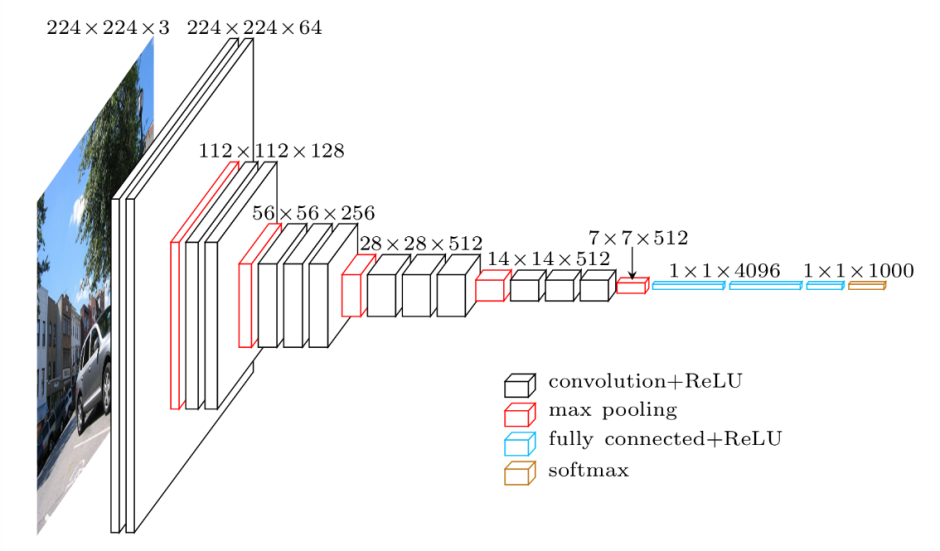

In [4]:
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, Flatten, MaxPooling2D, Dropout, Dense

In [5]:
!pip install split-folders

import splitfolders

splitfolders.ratio(
    '/content/lungcancerdata',
    output='/content/split_data',
    ratio=(0.75,0.10,0.15)
)

Copying files: 15000 files [00:08, 1853.79 files/s]


In [6]:
# setting up all the directories just to avoid any confusions

train_dir = '/content/split_data/train'
test_dir = '/content/split_data/test'
val_dir = '/content/split_data/val'

img_width, img_height = 224,224
batch_size = 32
epochs = 20
num_classes = 4 # This is based on our dataset

In [7]:
# load the datasets without the validation split because we already have the val data provided
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size
)

Found 11250 files belonging to 3 classes.


In [8]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size
)

Found 2250 files belonging to 3 classes.


In [9]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size
)

Found 1500 files belonging to 3 classes.


In [10]:
# we have less data, so we will also use data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [11]:
# applying the data augmentatino only on the training data
train_dataset = train_dataset.map(lambda x,y: (data_augmentation(x, training=True),y))

In [12]:
# Prefetch the datasets to get better performance, we can do this by using autotune
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

here I can directly import the vgg16 model, but it's better first to write the architecture manually and try training the custom dataset to see what happens.
In our case, since it's xray images, it will be hard

In [ ]:
def build_vgg16(input_shape=(224,224,3), num_classes=4):
  model = Sequential()

  # Input Layer
  model.add(layers.Input(shape=input_shape))

  # Normalization Layer
  model.add(Rescaling(1./255))

  # Block 1
  model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
  model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
  model.add(MaxPooling2D((2,2), strides=(2,2)))

  # Block 2
  model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
  model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
  model.add(MaxPooling2D((2,2), strides=(2,2)))

  # Block 3
  model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
  model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
  model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

  # Block 4
  model.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

  # Block 5
  model.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

  # FC layer
  model.add(Flatten())

  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(num_classes, activation='softmax')) # softmax cuz we have classification data

  return model

In [ ]:
model = build_vgg16(num_classes=num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,38

 Total params: 134,276,932 (512.23 MB)

 Trainable params: 134,276,932 (512.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=epochs
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 338s 831ms/step - accuracy: 0.3335 - loss: 1.1696 - val_accuracy: 0.3333 - val_loss: 1.0999
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 224s 635ms/step - accuracy: 0.3307 - loss: 1.1029 - val_accuracy: 0.3333 - val_loss: 1.1018
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 222s 629ms/step - accuracy: 0.3303 - loss: 1.1017 - val_accuracy: 0.3333 - val_loss: 1.1012
Epoch 4/20
  4/352 ━━━━━━━━━━━━━━━━━━━━ 3:47 654ms/step - accuracy: 0.3971 - loss: 1.0943

KeyboardInterrupt: 

as we can see simply, that the accuracy and the validation accuracy are both not improving. We need better weights which is why we will not try transfer learning

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

NameError: name 'history' is not defined

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.3361 - loss: 1.1005
Test Accuracy: 33.33%


In [ ]:
# Train set predictions
y_train_true = np.concatenate([y for x, y in train_dataset], axis=0)
y_train_pred = model.predict(train_dataset)
y_train_pred = np.argmax(y_train_pred, axis=1)

# Validation set predictions
y_val_true = np.concatenate([y for x, y in validation_dataset], axis=0)
y_val_pred = model.predict(validation_dataset)
y_val_pred = np.argmax(y_val_pred, axis=1)

# Test set predictions
y_test_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_test_pred = model.predict(test_dataset)
y_test_pred = np.argmax(y_test_pred, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Train Confusion Matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# Validation Confusion Matrix
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

# Test Confusion Matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

# Adjust layout
plt.tight_layout()
plt.show()

# Results: Not good at all

# Now we can try Transfer Learning

# Transfer Learning : Feature Extration

In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input

Firstly, we will do Feature Extration Method where we freeze the entire base model and just train the fully connected layer

In [14]:
# loading the pretrained vgg16 model

base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_tensor=Input(shape=(img_width,img_height, 3)))
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
for layer in base_model.layers:
  layer.trainable = False

In [16]:
# Building the model

model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax') # here we have 3 output classes : adenocarcinoma, benign and squamous_cell_carcinoma
])

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if labels are one-hot encoded
              metrics=['accuracy'])

In [18]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 188s 487ms/step - accuracy: 0.8603 - loss: 1.9355 - val_accuracy: 0.9607 - val_loss: 0.1421
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 149s 424ms/step - accuracy: 0.9318 - loss: 0.2593 - val_accuracy: 0.9680 - val_loss: 0.0806
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 203s 427ms/step - accuracy: 0.9473 - loss: 0.1468 - val_accuracy: 0.9740 - val_loss: 0.0711
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 201s 426ms/step - accuracy: 0.9490 - loss: 0.1352 - val_accuracy: 0.9767 - val_loss: 0.0492
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 150s 427ms/step - accuracy: 0.9620 - loss: 0.0965 - val_accuracy: 0.9820 - val_loss: 0.0507
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 147s 417ms/step - accuracy: 0.9610 - loss: 0.1037 - val_accuracy: 0.9867 - val_loss: 0.0355
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 150s 425ms/step - accuracy: 0.9693 - loss: 0.0819 - val_accuracy: 0.9813 - val_loss: 0.0444
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 201s 423ms/step - accuracy: 0.9679 -

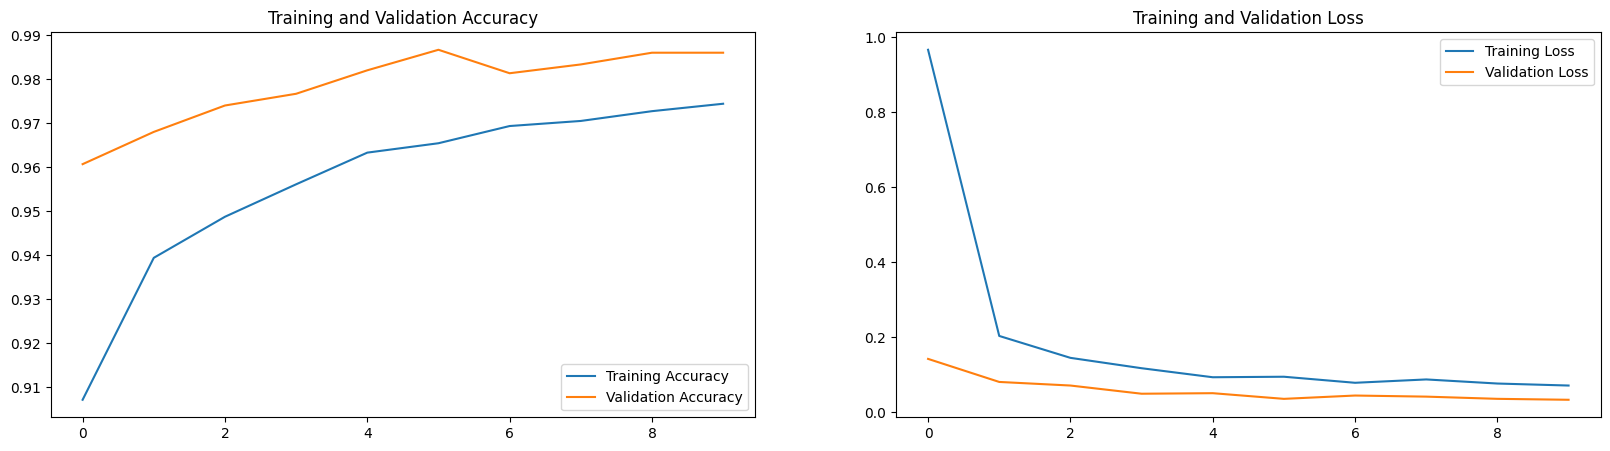

In [19]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 288ms/step - accuracy: 0.9806 - loss: 0.0514
Test Accuracy: 98.40%


In [23]:
# Train set predictions
y_train_true = np.concatenate([y for x, y in train_dataset], axis=0)
y_train_pred = model.predict(train_dataset)
y_train_pred = np.argmax(y_train_pred, axis=1)

# Validation set predictions
y_val_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_val_pred = model.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred, axis=1)

# Test set predictions
y_test_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_test_pred = model.predict(test_dataset)
y_test_pred = np.argmax(y_test_pred, axis=1)

352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 405ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 215ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step


In [24]:
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

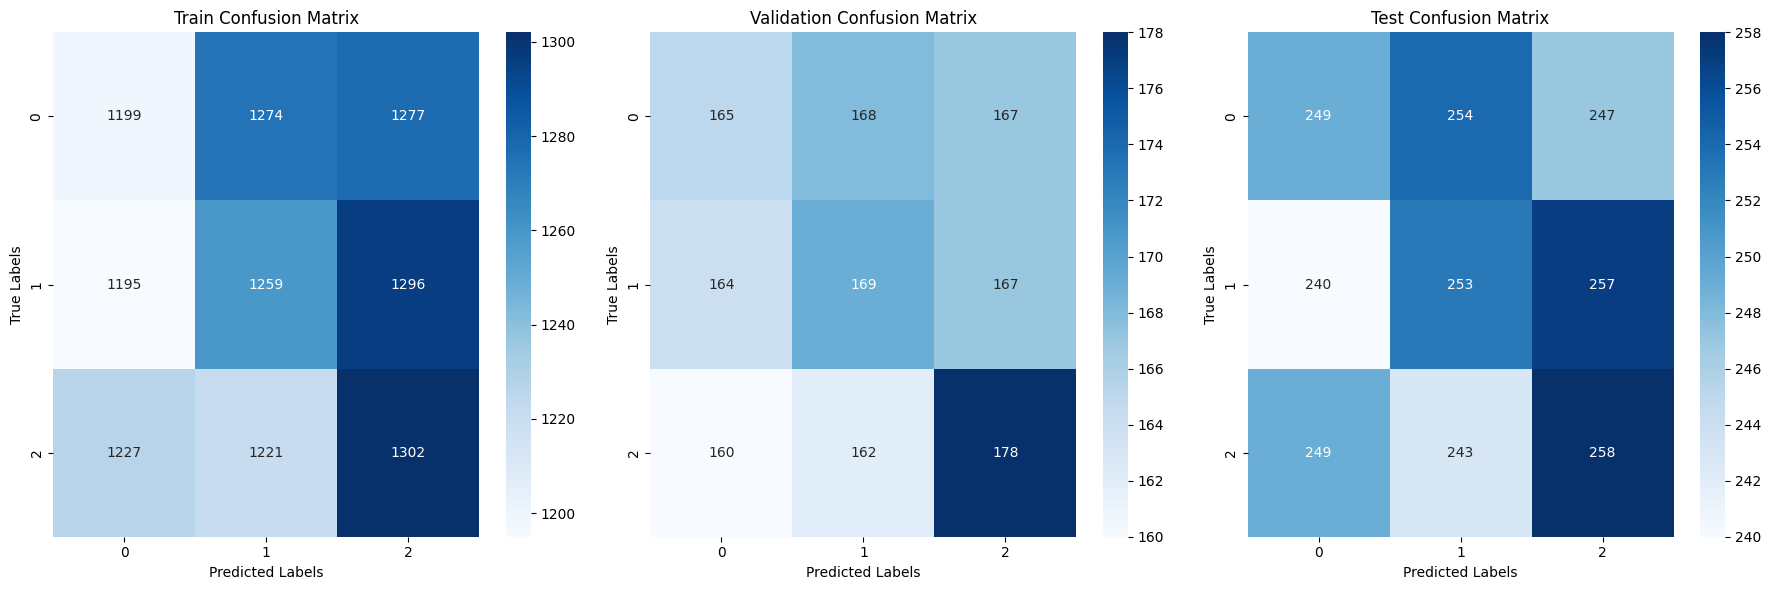

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Train Confusion Matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# Validation Confusion Matrix
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

# Test Confusion Matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

# Adjust layout
plt.tight_layout()
plt.show()

# Transfer Learning : Fine Tuning

In fine tuning, we unfreeze the last few layers of the base model and train those along with the fully connected layer.

In [26]:
# Load VGG16 with pre-trained ImageNet weights, excluding the top (fully connected) layers
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_tensor=Input(shape=(224, 224, 3)))

# Freeze the first few layers
for layer in base_model.layers[:13]:  # Freeze first 13 layers, adjust as needed
    layer.trainable = False

# Unfreeze the remaining layers
for layer in base_model.layers[13:]:
    layer.trainable = True

In [29]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 5,275,456 (20.12 MB)

In [30]:
# Building the model

model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax') # here we have 3 output classes : adenocarcinoma, benign and squamous_cell_carcinoma
])

In [31]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if labels are one-hot encoded
              metrics=['accuracy'])

In [32]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 185s 490ms/step - accuracy: 0.8459 - loss: 0.8108 - val_accuracy: 0.9527 - val_loss: 0.1291
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 165s 468ms/step - accuracy: 0.9522 - loss: 0.1334 - val_accuracy: 0.9787 - val_loss: 0.0564
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 168s 477ms/step - accuracy: 0.9734 - loss: 0.0716 - val_accuracy: 0.9960 - val_loss: 0.0176
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 165s 469ms/step - accuracy: 0.9820 - loss: 0.0494 - val_accuracy: 0.9793 - val_loss: 0.0566
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 166s 472ms/step - accuracy: 0.9717 - loss: 0.0863 - val_accuracy: 0.9973 - val_loss: 0.0151
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 165s 468ms/step - accuracy: 0.9854 - loss: 0.0450 - val_accuracy: 0.9667 - val_loss: 0.0993
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 166s 472ms/step - accuracy: 0.9787 - loss: 0.0575 - val_accuracy: 0.9940 - val_loss: 0.0151
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 165s 467ms/step - accuracy: 0.9885 -

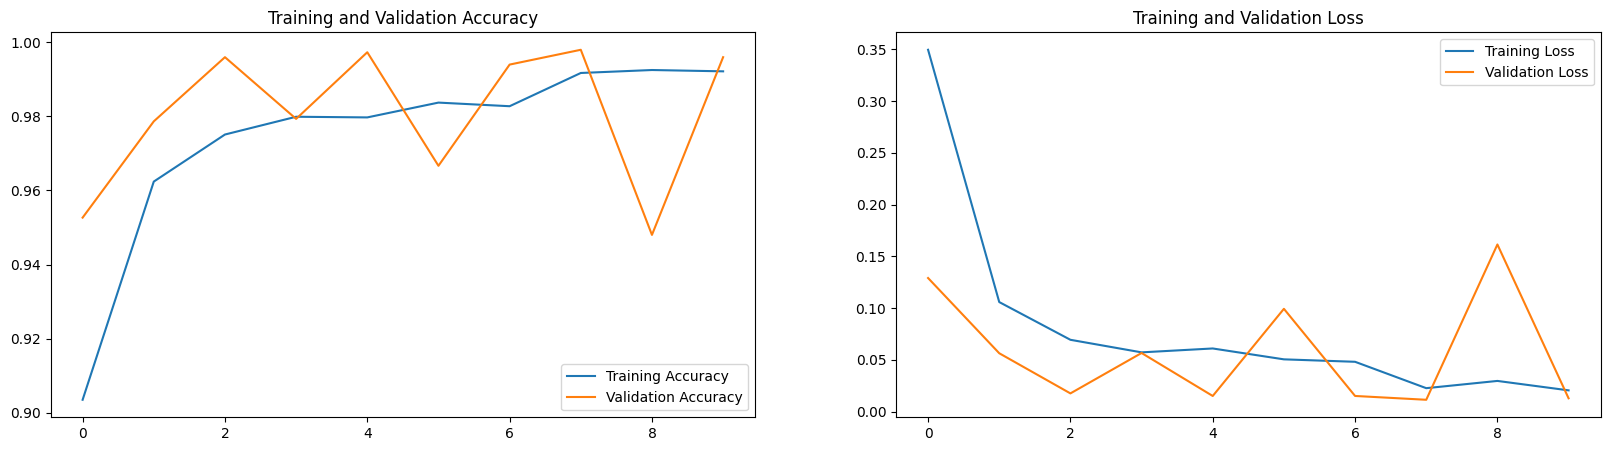

In [33]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 203ms/step - accuracy: 0.9899 - loss: 0.0159
Test Accuracy: 99.07%


In [35]:
# Train set predictions
y_train_true = np.concatenate([y for x, y in train_dataset], axis=0)
y_train_pred = model.predict(train_dataset)
y_train_pred = np.argmax(y_train_pred, axis=1)

# Validation set predictions
y_val_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_val_pred = model.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred, axis=1)

# Test set predictions
y_test_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_test_pred = model.predict(test_dataset)
y_test_pred = np.argmax(y_test_pred, axis=1)

352/352 ━━━━━━━━━━━━━━━━━━━━ 146s 412ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step


In [36]:
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

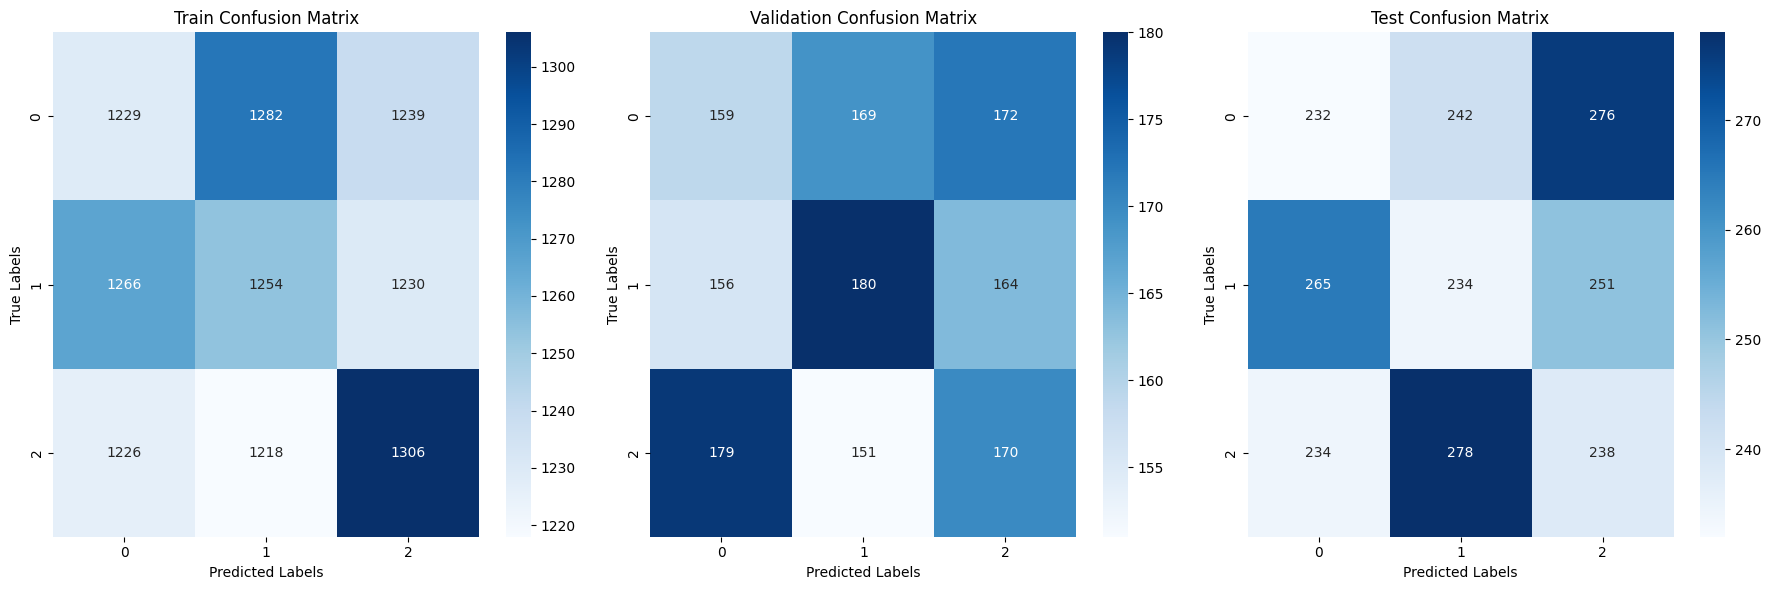

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Train Confusion Matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# Validation Confusion Matrix
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

# Test Confusion Matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

# Adjust layout
plt.tight_layout()
plt.show()